In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv('Fish.csv')

In [4]:
df.isna().sum()

Species    0
Weight     0
Length1    0
Length2    0
Length3    0
Height     0
Width      0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.corr(numeric_only=True)

,Weight,Length1,Length2,Length3,Height,Width
Weight,1.000000,0.915712,0.918618,0.923044,0.724345,0.886507
Length1,0.915712,1.000000,0.999517,0.992031,0.625378,0.867050
Length2,0.918618,0.999517,1.000000,0.994103,0.640441,0.873547
Length3,0.923044,0.992031,0.994103,1.000000,0.703409,0.878520
Height,0.724345,0.625378,0.640441,0.703409,1.000000,0.792881
Width,0.886507,0.867050,0.873547,0.878520,0.792881,1.000000


<Axes: xlabel='Species', ylabel='Weight'>

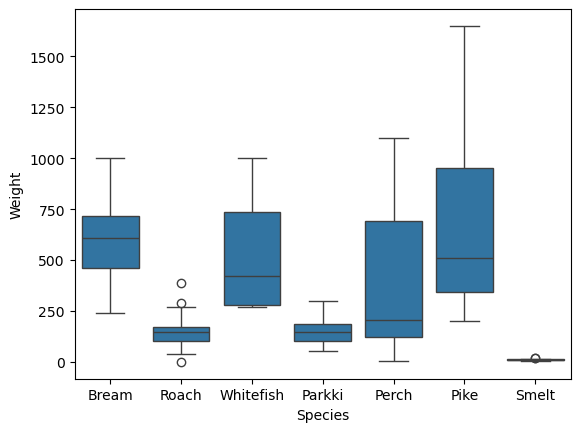

In [7]:
sns.boxplot(data=df,x='Species',y='Weight')

In [8]:
x=df.drop('Weight',axis=1)
x=pd.get_dummies(x,drop_first=True)
y=df["Weight"]
x

,Length1,Length2,Length3,Height,Width,Species_Parkki,Species_Perch,Species_Pike,Species_Roach,Species_Smelt,Species_Whitefish
0,23.2,25.4,30.0,11.5200,4.0200,False,False,False,False,False,False
1,24.0,26.3,31.2,12.4800,4.3056,False,False,False,False,False,False
2,23.9,26.5,31.1,12.3778,4.6961,False,False,False,False,False,False
3,26.3,29.0,33.5,12.7300,4.4555,False,False,False,False,False,False
4,26.5,29.0,34.0,12.4440,5.1340,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
154,11.5,12.2,13.4,2.0904,1.3936,False,False,False,False,True,False
155,11.7,12.4,13.5,2.4300,1.2690,False,False,False,False,True,False
156,12.1,13.0,13.8,2.2770,1.2558,False,False,False,False,True,False
157,13.2,14.3,15.2,2.8728,2.0672,False,False,False,False,True,False


In [9]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=3)
x_train_poly=poly.fit_transform(x_train)
x_test_poly=poly.transform(x_test)
model=LinearRegression()
model.fit(x_train_poly,y_train)
print(model.coef_)
print(model.intercept_)
y_pred=model.predict(x_test_poly)
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

[ 1.50276566e+00  2.64156846e+03 -1.96236736e+04  3.19798667e+04
 -1.09809966e+05  4.34081434e+04 -4.04449163e+04 -7.24953374e+04
 -5.53906250e+04 -7.79905735e+04 -1.09214888e+04 -1.66204664e+01
  9.55329630e+04 -1.68276860e+05 -9.30573087e+03  1.80171090e+04
 -2.85300127e+04 -1.40899999e+03  1.20523723e+04  4.02309978e+04
  6.23354197e+03 -1.12509226e+04 -2.32726562e+02  7.44580492e+02
  1.47392021e+05 -6.55642876e+04  7.73832686e+04  6.58932522e+03
 -2.56841280e+03 -8.22899789e+03 -9.45186928e+03 -1.20434017e+02
 -2.65342883e+02 -6.62715137e+04  4.52377252e+04 -4.26639580e+04
 -1.82559083e+04 -1.68933944e+04 -3.39279333e+04 -1.79005313e+03
 -1.14310150e+04 -3.03395696e+02  4.16717968e+03 -5.90569742e+03
  3.96550655e+04  5.60108550e+04  6.13909497e+04  3.97876519e+04
  4.97779158e+03 -9.12391976e+01 -5.95554931e+03  1.72164796e+04
 -1.94261726e+04 -5.34044622e+04 -1.45725790e+04  4.47608971e+04
 -5.46726680e+01 -4.04448316e+04 -5.32052695e-08  2.71903389e-10
 -1.20272716e-08 -3.39525

In [10]:
mean_absolute_error(y_test,y_pred)

4045.7569136940515

In [11]:
mean_squared_error(y_test,y_pred)

56770847.840270445

In [12]:
r2_score(y_test,y_pred)

-398.1221349819577

In [13]:
x_train.head(1)

,Length1,Length2,Length3,Height,Width,Species_Parkki,Species_Perch,Species_Pike,Species_Roach,Species_Smelt,Species_Whitefish
75,15.0,16.2,17.2,4.5924,2.6316,False,True,False,False,False,False


In [14]:
model.predict(poly.transform([[10,10,10,5,5,0,1,0,0,0,0]]))

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


array([-71098.53375215])